In [85]:
# pip install seaborn

In [86]:
# pip install scikit-learn

In [87]:
import pandas as pd

In [88]:
df=pd.read_csv("LoanApprovalPrediction(2).csv")
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [89]:
df.shape

(614, 13)

In [90]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [92]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [93]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [94]:
for i in df.columns:
    print(df[i].unique(),i)
    print('*'*100)
    print(df[i].value_counts())
    print('*'*100)

['LP001002' 'LP001003' 'LP001005' 'LP001006' 'LP001008' 'LP001011'
 'LP001013' 'LP001014' 'LP001018' 'LP001020' 'LP001024' 'LP001027'
 'LP001028' 'LP001029' 'LP001030' 'LP001032' 'LP001034' 'LP001036'
 'LP001038' 'LP001041' 'LP001043' 'LP001046' 'LP001047' 'LP001050'
 'LP001052' 'LP001066' 'LP001068' 'LP001073' 'LP001086' 'LP001087'
 'LP001091' 'LP001095' 'LP001097' 'LP001098' 'LP001100' 'LP001106'
 'LP001109' 'LP001112' 'LP001114' 'LP001116' 'LP001119' 'LP001120'
 'LP001123' 'LP001131' 'LP001136' 'LP001137' 'LP001138' 'LP001144'
 'LP001146' 'LP001151' 'LP001155' 'LP001157' 'LP001164' 'LP001179'
 'LP001186' 'LP001194' 'LP001195' 'LP001197' 'LP001198' 'LP001199'
 'LP001205' 'LP001206' 'LP001207' 'LP001213' 'LP001222' 'LP001225'
 'LP001228' 'LP001233' 'LP001238' 'LP001241' 'LP001243' 'LP001245'
 'LP001248' 'LP001250' 'LP001253' 'LP001255' 'LP001256' 'LP001259'
 'LP001263' 'LP001264' 'LP001265' 'LP001266' 'LP001267' 'LP001273'
 'LP001275' 'LP001279' 'LP001280' 'LP001282' 'LP001289' 'LP001

In [95]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [96]:
df.isna().sum()/len(df)*100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [97]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

credit history categorical ayyath kond mode create cheyyth

In [98]:
df['Credit_History'].mode()

0    1.0
Name: Credit_History, dtype: float64

In [99]:
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_10820\1608471621.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)


In [100]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [101]:
df.ffill(inplace=True)

In [102]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           1
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [103]:
df.bfill(inplace=True)

In [104]:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [105]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [106]:
cols = ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for i in cols:
    print(df[i].unique(), i)
    print('*'*43)

['LP001002' 'LP001003' 'LP001005' 'LP001006' 'LP001008' 'LP001011'
 'LP001013' 'LP001014' 'LP001018' 'LP001020' 'LP001024' 'LP001027'
 'LP001028' 'LP001029' 'LP001030' 'LP001032' 'LP001034' 'LP001036'
 'LP001038' 'LP001041' 'LP001043' 'LP001046' 'LP001047' 'LP001050'
 'LP001052' 'LP001066' 'LP001068' 'LP001073' 'LP001086' 'LP001087'
 'LP001091' 'LP001095' 'LP001097' 'LP001098' 'LP001100' 'LP001106'
 'LP001109' 'LP001112' 'LP001114' 'LP001116' 'LP001119' 'LP001120'
 'LP001123' 'LP001131' 'LP001136' 'LP001137' 'LP001138' 'LP001144'
 'LP001146' 'LP001151' 'LP001155' 'LP001157' 'LP001164' 'LP001179'
 'LP001186' 'LP001194' 'LP001195' 'LP001197' 'LP001198' 'LP001199'
 'LP001205' 'LP001206' 'LP001207' 'LP001213' 'LP001222' 'LP001225'
 'LP001228' 'LP001233' 'LP001238' 'LP001241' 'LP001243' 'LP001245'
 'LP001248' 'LP001250' 'LP001253' 'LP001255' 'LP001256' 'LP001259'
 'LP001263' 'LP001264' 'LP001265' 'LP001266' 'LP001267' 'LP001273'
 'LP001275' 'LP001279' 'LP001280' 'LP001282' 'LP001289' 'LP001

In [107]:
df.drop(columns=['Loan_ID'], inplace=True)


In [108]:
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(int)
df['Dependents'].dtype

dtype('int64')

In [109]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le_cols = ['Gender', 'Married', 'Education', 
               'Self_Employed', 'Loan_Status']

for col in le_cols:
    df[col] = le.fit_transform(df[col])


In [110]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
ohe_col = ohe.fit_transform(df[["Property_Area"]])

In [111]:
df.duplicated().sum()

np.int64(0)

In [112]:
ohe_df = pd.DataFrame(
    ohe_col,
    columns=ohe.get_feature_names_out(['Property_Area']),
    index=df.index)


In [113]:
df.drop(columns=['Property_Area'], inplace=True)


In [114]:
df = pd.concat([df,ohe_df], axis=1)


In [115]:
df.corr()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
Gender,1.000000,0.371532,0.164475,0.049480,0.011676,0.046230,0.086991,0.100475,-0.080085,0.005658,0.012213,0.075892,-0.109961,0.040160
Married,0.371532,1.000000,0.333841,0.014097,-0.000257,0.049052,0.077760,0.133471,-0.099170,0.009519,0.089072,-0.004606,0.001468,0.002938
Dependents,0.164475,0.333841,1.000000,0.054909,0.044505,0.115036,0.026683,0.141971,-0.085453,-0.065459,-0.003361,-0.011146,0.012558,-0.002189
Education,0.049480,0.014097,0.054909,1.000000,-0.008734,-0.140760,-0.062290,-0.151763,-0.080674,-0.073658,-0.085884,0.077520,-0.039410,-0.034279
Self_Employed,0.011676,-0.000257,0.044505,-0.008734,1.000000,0.122728,-0.021807,0.099519,-0.035485,0.006209,0.009035,0.030238,0.003528,-0.032892
ApplicantIncome,0.046230,0.049052,0.115036,-0.140760,0.122728,1.000000,-0.116605,0.533336,-0.042849,-0.018615,-0.004710,0.015829,-0.014246,-0.000598
CoapplicantIncome,0.086991,0.077760,0.026683,-0.062290,-0.021807,-0.116605,1.000000,0.189820,-0.067336,0.011134,-0.059187,0.005329,-0.027044,0.022776
LoanAmount,0.100475,0.133471,0.141971,-0.151763,0.099519,0.533336,0.189820,1.000000,0.023657,0.003186,-0.044622,0.036845,-0.006284,-0.029149
Loan_Amount_Term,-0.080085,-0.099170,-0.085453,-0.080674,-0.035485,-0.042849,-0.067336,0.023657,1.000000,-0.013754,-0.033378,0.028213,0.055075,-0.084171
Credit_History,0.005658,0.009519,-0.065459,-0.073658,0.006209,-0.018615,0.011134,0.003186,-0.013754,1.000000,0.540556,-0.020906,0.035976,-0.016934


In [116]:
# pip install matplotlib

box plot

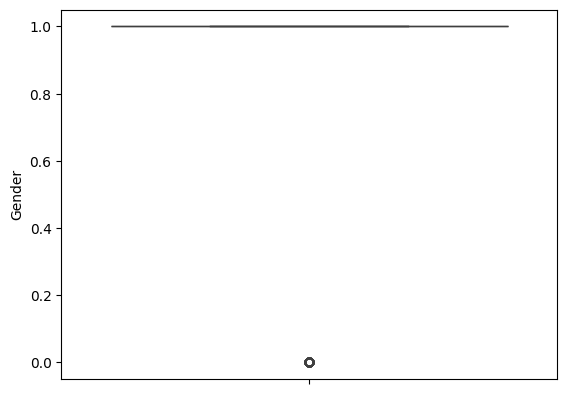

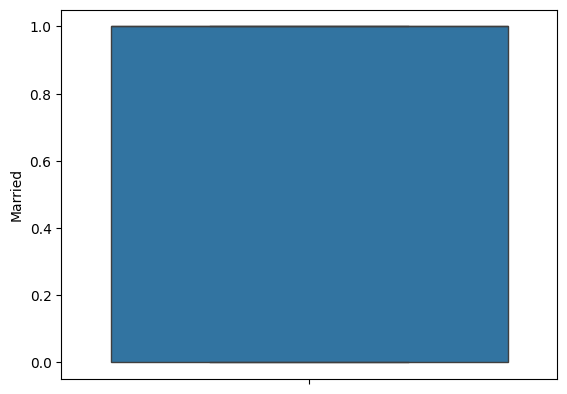

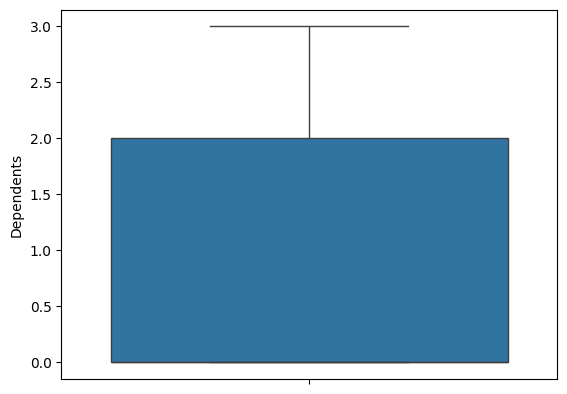

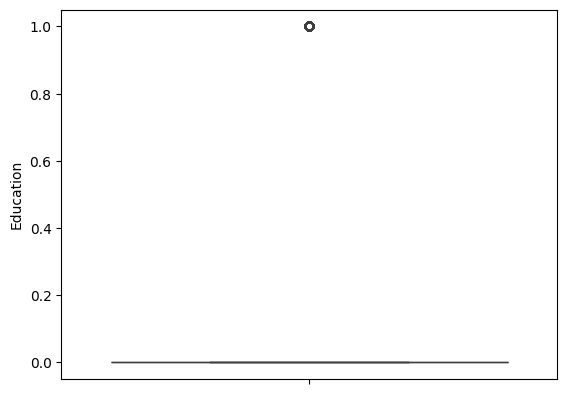

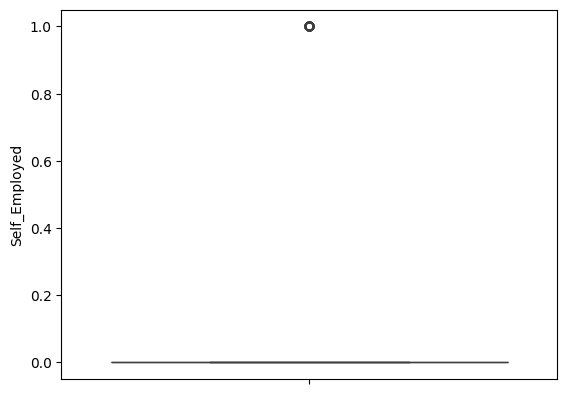

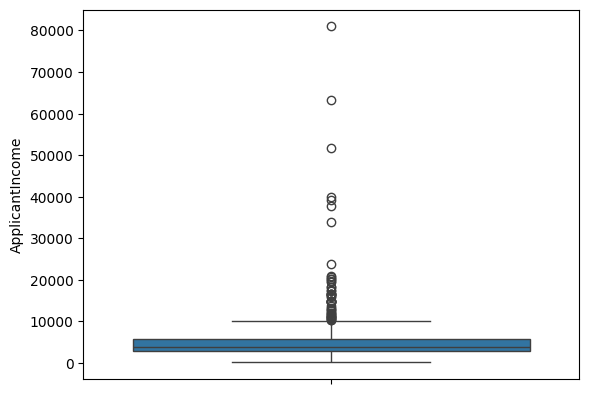

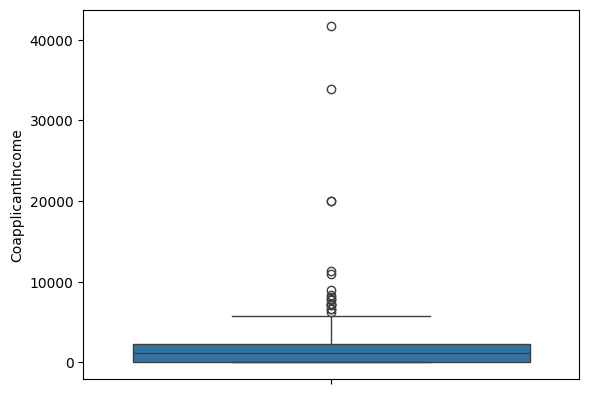

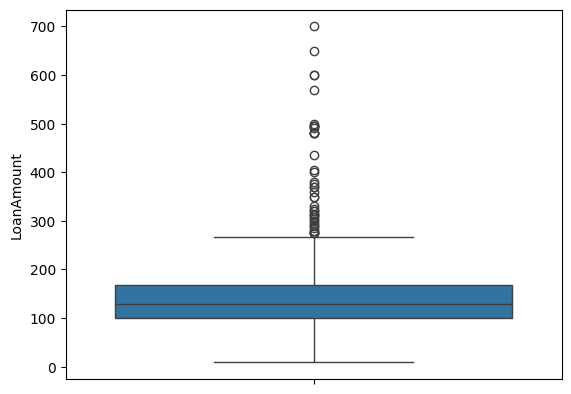

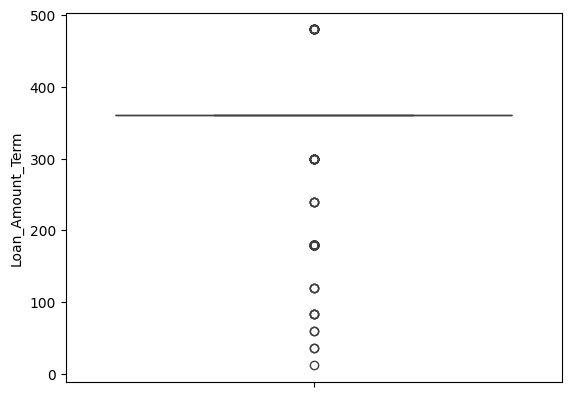

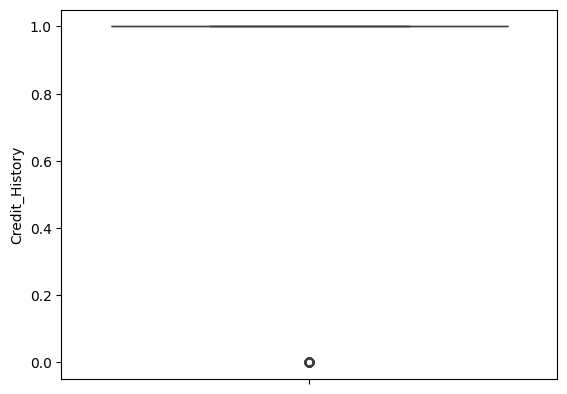

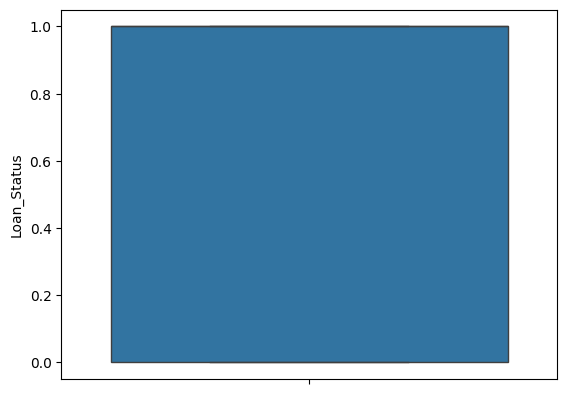

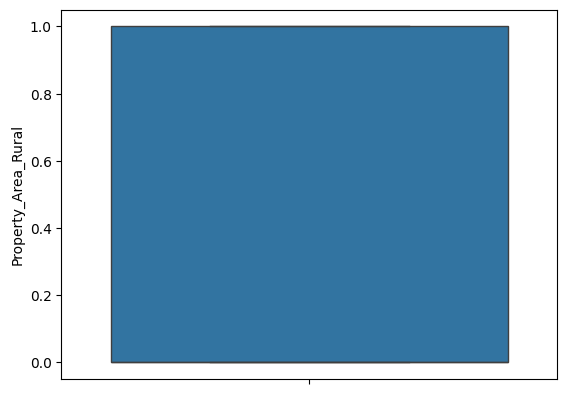

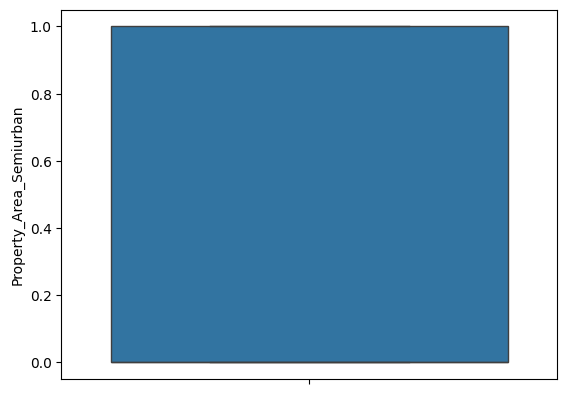

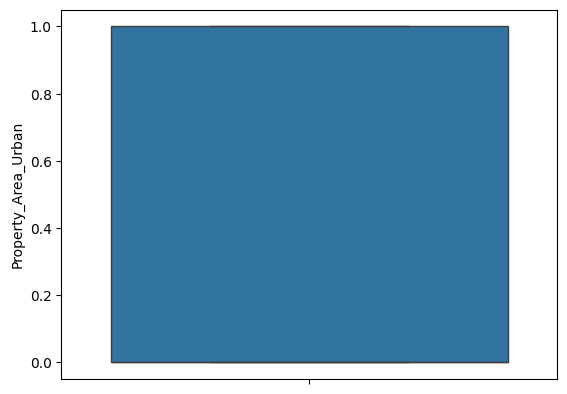

In [117]:
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

In [118]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop('Loan_Status', errors='ignore')


In [119]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower, upper)


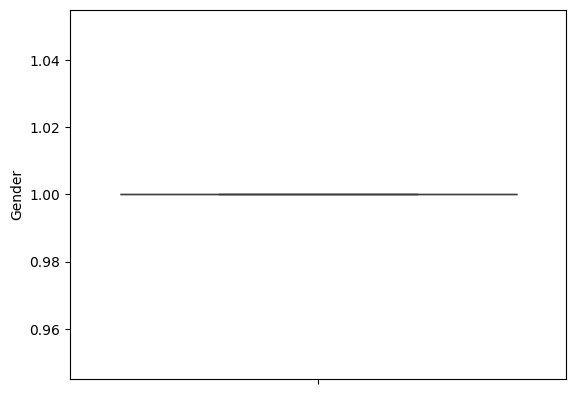

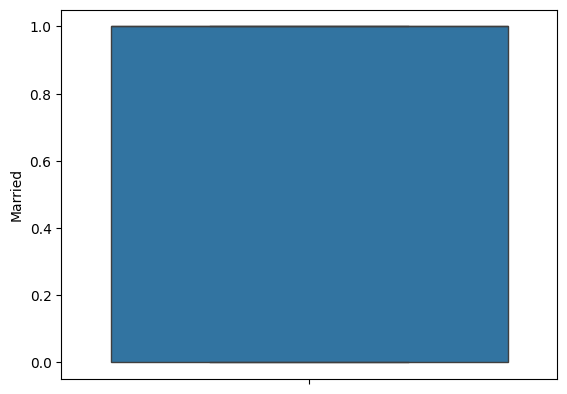

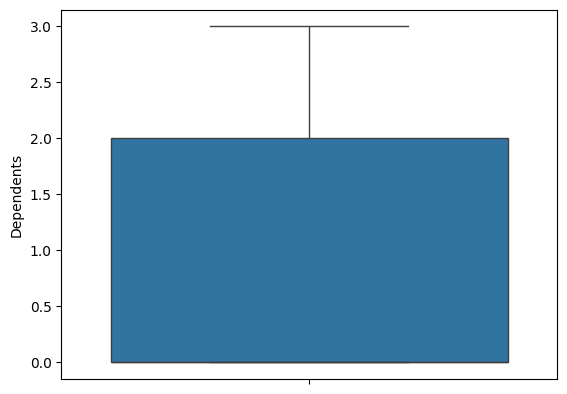

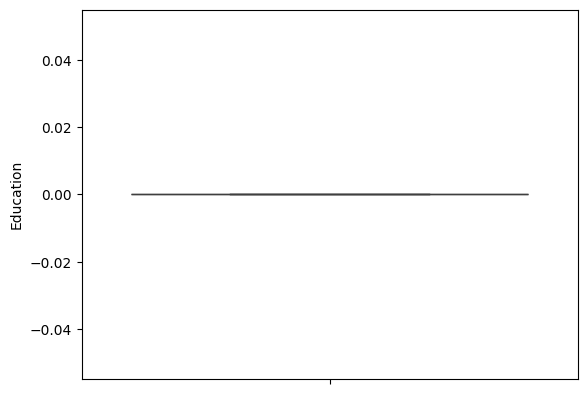

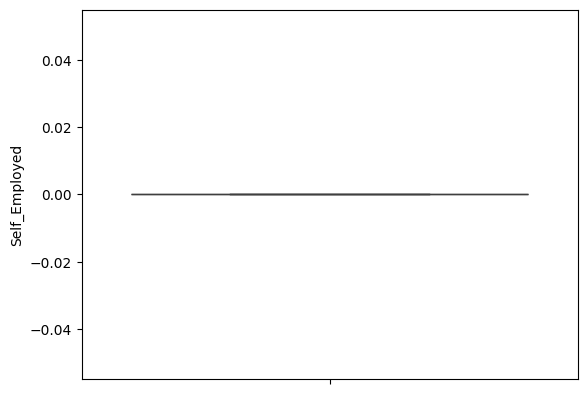

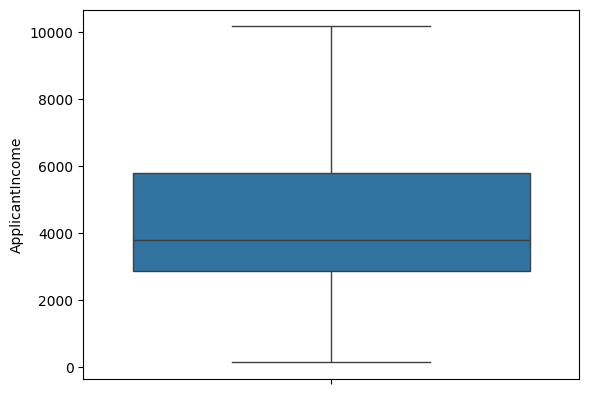

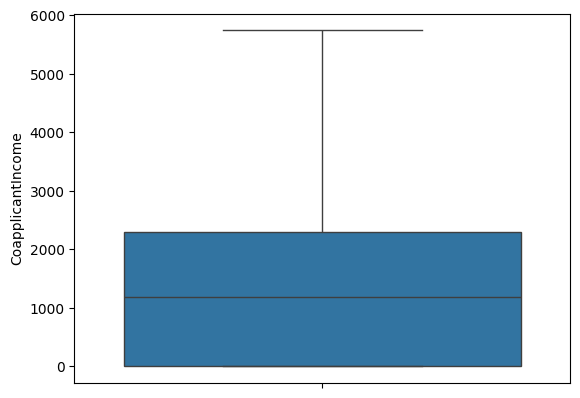

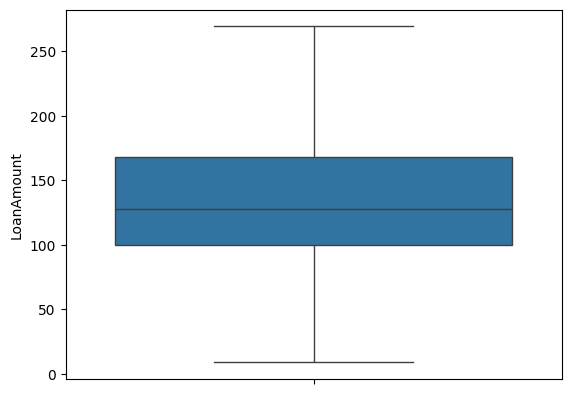

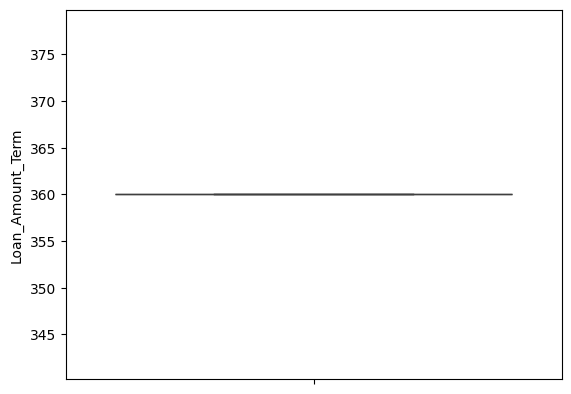

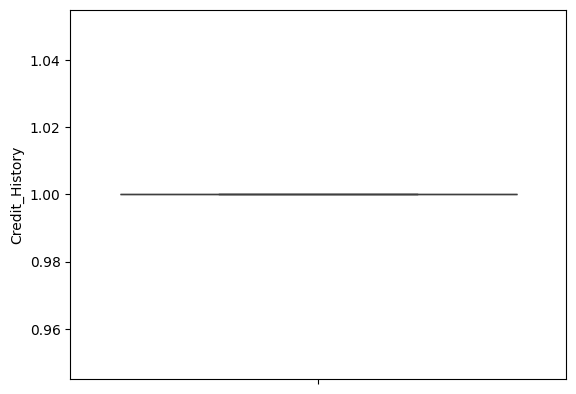

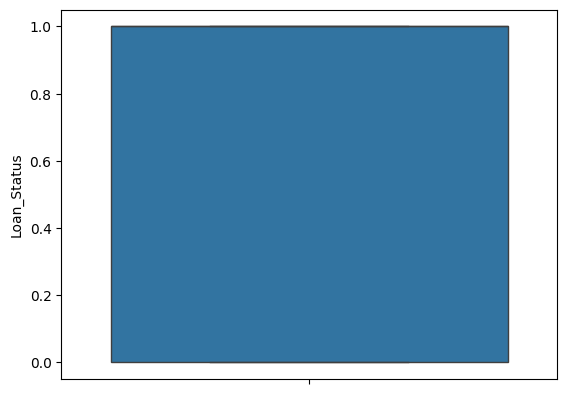

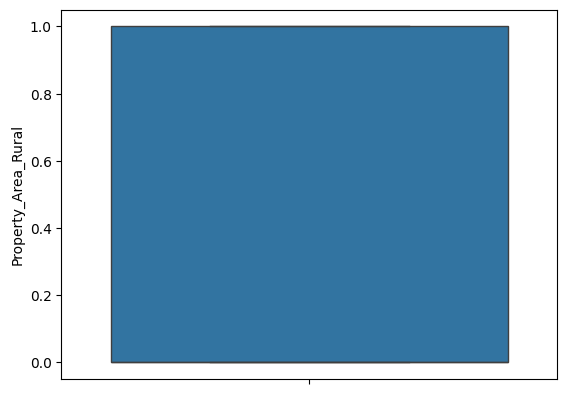

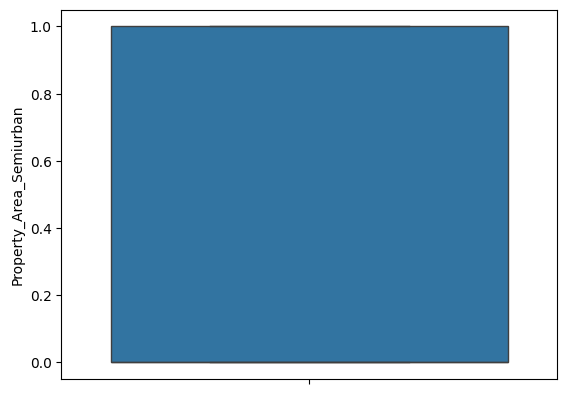

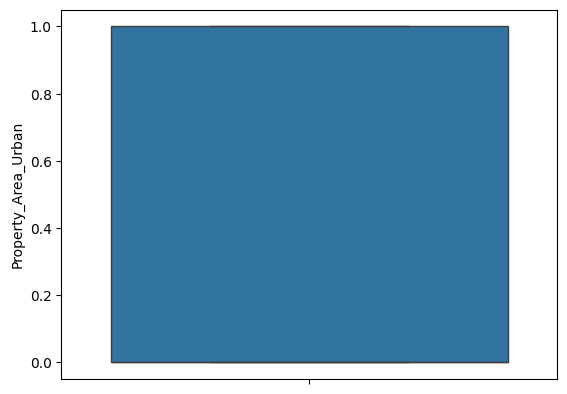

In [120]:
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

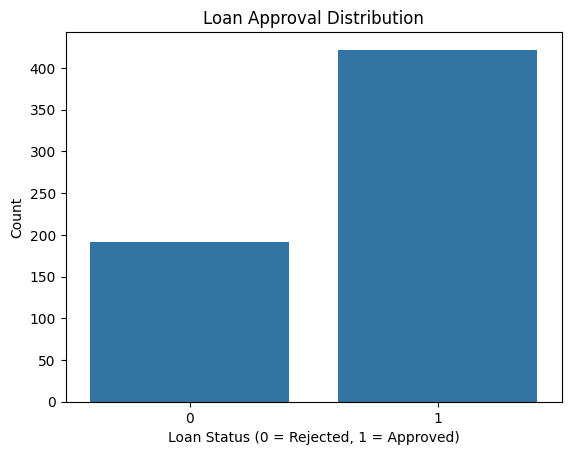

In [121]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Loan_Status', data=df)
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Status (0 = Rejected, 1 = Approved)')
plt.ylabel('Count')
plt.show()


The dataset shows an imbalance where approved loans are higher than rejected loans

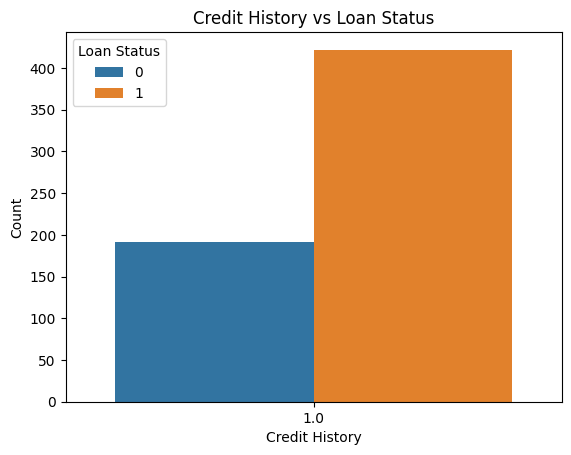

In [122]:
sns.countplot(x='Credit_History', hue='Loan_Status', data=df)
plt.title('Credit History vs Loan Status')
plt.xlabel('Credit History')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.show()


Applicants with a good credit history have a significantly higher chance of loan approval

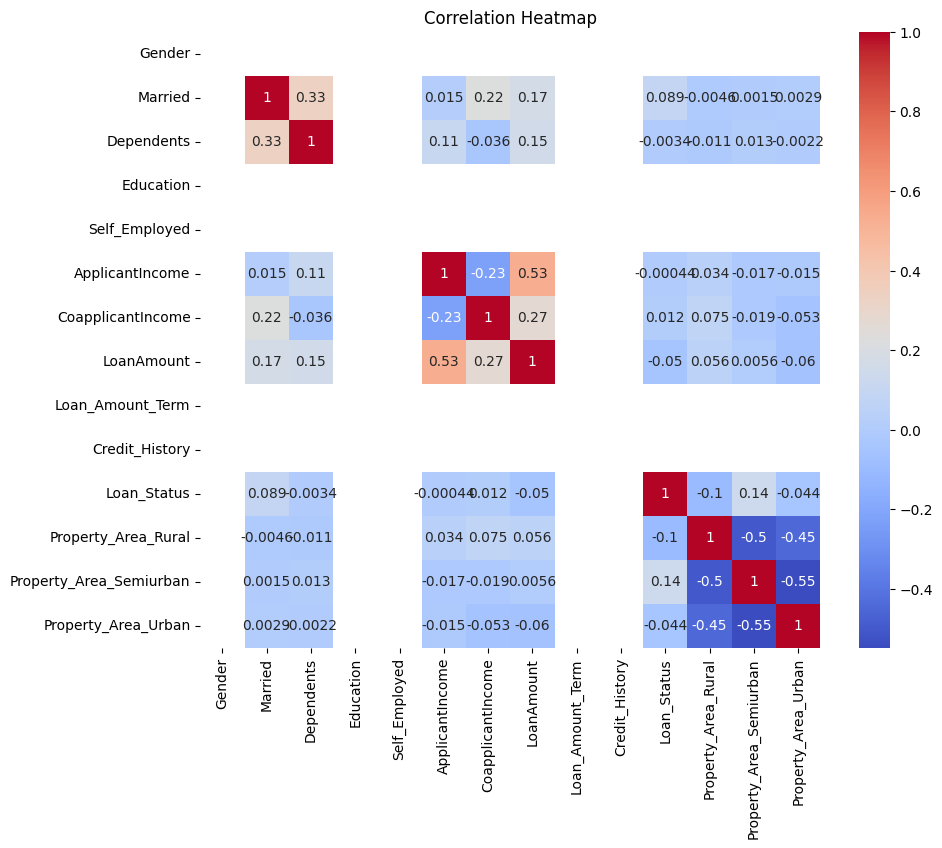

In [123]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()




Credit_History shows the strongest positive correlation with loan approval
income and loan amount have weaker influence.

FEATURE SCALING


In [124]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']


In [125]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,0.0,0.0,1.0
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,1.0,0.0,0.0
2,1,1,0,0,0,3000.0,0.0,66.0,360.0,1.0,0.0,0.0,1.0
3,1,1,0,0,0,2583.0,2358.0,120.0,360.0,1.0,0.0,0.0,1.0
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,0.0,0.0,1.0


In [126]:
y.value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [127]:
# pip install imbalanced-learn

Train–Test Split

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [ ]:
# pip install imblearn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement imblearn (from versions: none)
ERROR: No matching distribution found for imblearn


In [130]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
from sklearn.svm import SVC
svm = SVC()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)


lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
svm_pred = svm.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Logistic:", accuracy_score(y_test, lr_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("SVM:", accuracy_score(y_test, svm_pred))

Logistic: 0.6883116883116883
Decision Tree: 0.5584415584415584
Random Forest: 0.6363636363636364
SVM: 0.6883116883116883


In [131]:
from imblearn.over_sampling import SMOTE

In [132]:
# pip install imblearn


In [133]:
import sklearn
print(sklearn.__version__)


1.6.1


In [ ]:
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train,y_train)
print('After SMOTE:',y_train_bal.value_counts())


After SMOTE: Loan_Status
0    316
1    316
Name: count, dtype: int64


In [146]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)


# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train_bal)
# X_test_scaled = scaler.transform(X_test)

In [136]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train,y_train)


KNeighborsClassifier(n_neighbors=7)

In [137]:
y_pred_knn_bal = knn.predict(X_test)
y_pred_knn_bal

array([1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1])

In [138]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print(confusion_matrix(y_test, y_pred_knn_bal))
print(accuracy_score(y_test, y_pred_knn_bal))
print(classification_report(y_test, y_pred_knn_bal))


[[12 36]
 [19 87]]
0.6428571428571429
              precision    recall  f1-score   support

           0       0.39      0.25      0.30        48
           1       0.71      0.82      0.76       106

    accuracy                           0.64       154
   macro avg       0.55      0.54      0.53       154
weighted avg       0.61      0.64      0.62       154



In [139]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy',max_depth=6,random_state=42)
dt.fit(X_train_bal,y_train_bal)
y_pred_dt = dt.predict(X_test)
y_pred_dt



array([0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1])

In [140]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
print(confusion_matrix(y_test,y_pred_dt))
print(accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[21 27]
 [33 73]]
0.6103896103896104
              precision    recall  f1-score   support

           0       0.39      0.44      0.41        48
           1       0.73      0.69      0.71       106

    accuracy                           0.61       154
   macro avg       0.56      0.56      0.56       154
weighted avg       0.62      0.61      0.62       154



In [147]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train_bal)
y_pred_lr = lr.predict(X_test_scaled)
y_pred_lr


# X_train_bal_scaled = scaler.fit_transform(X_train_bal)
# X_test_scaled = scaler.transform(X_test)

array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

In [148]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
print(confusion_matrix(y_test,y_pred_lr))
print(accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

[[24 24]
 [38 68]]
0.5974025974025974
              precision    recall  f1-score   support

           0       0.39      0.50      0.44        48
           1       0.74      0.64      0.69       106

    accuracy                           0.60       154
   macro avg       0.56      0.57      0.56       154
weighted avg       0.63      0.60      0.61       154



In [150]:
from sklearn.linear_model import LogisticRegression

ridge = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000
)

ridge.fit(X_train_scaled, y_train_bal)


LogisticRegression(max_iter=1000)

In [151]:
y_pred_ridge = ridge.predict(X_test_scaled)


In [152]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Ridge Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_ridge))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ridge))
print("Classification Report:\n", classification_report(y_test, y_pred_ridge))


Ridge Logistic Regression
Accuracy: 0.5974025974025974
Confusion Matrix:
 [[24 24]
 [38 68]]
Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.50      0.44        48
           1       0.74      0.64      0.69       106

    accuracy                           0.60       154
   macro avg       0.56      0.57      0.56       154
weighted avg       0.63      0.60      0.61       154



In [153]:
lasso = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)

lasso.fit(X_train_scaled, y_train_bal)


LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

In [154]:
y_pred_lasso = lasso.predict(X_test_scaled)


In [155]:
print("Lasso Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lasso))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lasso))
print("Classification Report:\n", classification_report(y_test, y_pred_lasso))


Lasso Logistic Regression
Accuracy: 0.5844155844155844
Confusion Matrix:
 [[23 25]
 [39 67]]
Classification Report:
               precision    recall  f1-score   support

           0       0.37      0.48      0.42        48
           1       0.73      0.63      0.68       106

    accuracy                           0.58       154
   macro avg       0.55      0.56      0.55       154
weighted avg       0.62      0.58      0.60       154



In [156]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def evaluate_model(model_name, y_test, y_pred):
    print(f"\n🔹 {model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


In [157]:
evaluate_model("KNN", y_test, y_pred_knn_bal)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Lasso Logistic Regression", y_test, y_pred_lasso)
evaluate_model("Ridge Logistic Regression", y_test, y_pred_ridge)



🔹 KNN
Accuracy: 0.6428571428571429
Confusion Matrix:
 [[12 36]
 [19 87]]
Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.25      0.30        48
           1       0.71      0.82      0.76       106

    accuracy                           0.64       154
   macro avg       0.55      0.54      0.53       154
weighted avg       0.61      0.64      0.62       154


🔹 Decision Tree
Accuracy: 0.6103896103896104
Confusion Matrix:
 [[21 27]
 [33 73]]
Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.44      0.41        48
           1       0.73      0.69      0.71       106

    accuracy                           0.61       154
   macro avg       0.56      0.56      0.56       154
weighted avg       0.62      0.61      0.62       154


🔹 Logistic Regression
Accuracy: 0.5974025974025974
Confusion Matrix:
 [[24 24]
 [38 68]]
Classification Report:
               precision   

In [158]:

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
from sklearn.svm import SVC
svm = SVC()

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)


lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)
svm_pred = svm.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Logistic:", accuracy_score(y_test, lr_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("SVM:", accuracy_score(y_test, svm_pred))

Logistic: 0.6883116883116883
Decision Tree: 0.577922077922078
Random Forest: 0.6363636363636364
SVM: 0.6883116883116883


In [159]:
import pandas as pd

accuracy_df = pd.DataFrame({
    "Model": [
        "KNN",
        "Decision Tree",
        "Logistic Regression",
        "Lasso Logistic Regression",
        "Ridge Logistic Regression"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn_bal),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_lasso),
        accuracy_score(y_test, y_pred_ridge)
    ]
})

print(accuracy_df.sort_values(by="Accuracy", ascending=False))


                       Model  Accuracy
0                        KNN  0.642857
1              Decision Tree  0.610390
2        Logistic Regression  0.597403
4  Ridge Logistic Regression  0.597403
3  Lasso Logistic Regression  0.584416


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


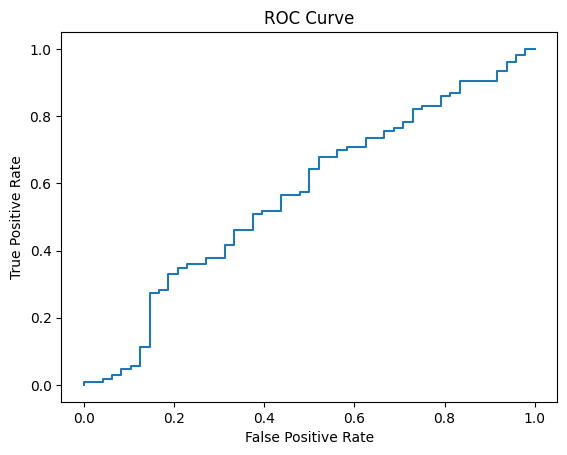

AUC Score: 0.5662342767295598


In [161]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))